In [152]:
import pandas as pd
import numpy as np
import seaborn as sns
import yaml

In [174]:
datasets = [
    "20260319T0823-tof",
    "20260323T1344-tof",
    "20260320T1036-tysk",
    "20260325T1030-tysk",
    "20260324T1339-it1",
]

skip = 10
grouped = 400

final_dfs = []

for d in datasets:
    with open(f"{d}/meta.yaml") as file:
        meta = yaml.safe_load(file)
    
    dfs = []
    for i in range(meta["Arduinos"]):
        df = pd.read_csv(f"{d}/a{i+1}-data.csv")
        del df["Timestamp"]
        df["Sound"] = df["Sound"].rolling(300).mean()
        
        df = df.mask(lambda x: x < 2)
        df = df[skip:-skip].copy()
        df = df.dropna()
        
        dfs.append(df)
    del meta["Arduinos"]

    df = pd.concat(dfs)
    df = df.groupby(df.index).mean()
    df = df.groupby(np.arange(len(df)) // grouped).mean()

    survey = pd.read_csv(f"{d}/survey.csv", header=0, names=["Timestamp", "Concentration", "Work"])
    del survey["Timestamp"]
    for col, mean in survey.mean().items():
        df[col] = mean

    for col, val in meta.items():
        df[col] = val
    
    final_dfs.append(df)

df = pd.concat(final_dfs)
df = df.reset_index(drop=True)


In [175]:
df

,Temperature (C),Humidity (%),Sound,Light,Concentration,Work,Room,Subject
0,20.240900,39.726887,14099.058497,343.203750,3.625000,3.125,619,tof
1,20.293725,39.692975,14586.702854,354.790000,3.625000,3.125,619,tof
2,20.905462,45.656625,15134.138749,517.826250,3.625000,3.125,619,tof
3,22.415012,68.624062,14415.859217,433.850000,3.625000,3.125,619,tof
4,22.462112,68.477487,16111.668981,522.787500,3.625000,3.125,619,tof
5,22.416196,66.550109,17714.494676,543.670290,3.625000,3.125,619,tof
6,22.101700,27.053800,14044.582219,513.380000,3.200000,2.600,619,tof
7,21.942700,26.650950,14822.636272,515.918750,3.200000,2.600,619,tof
8,21.831887,25.405738,13423.095510,508.445000,3.200000,2.600,619,tof
9,21.722550,26.943638,14236.159928,503.982500,3.200000,2.600,619,tof


<Axes: >

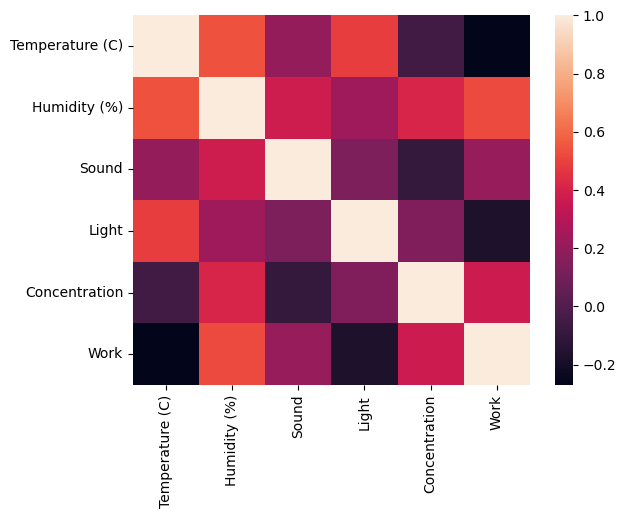

In [176]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)

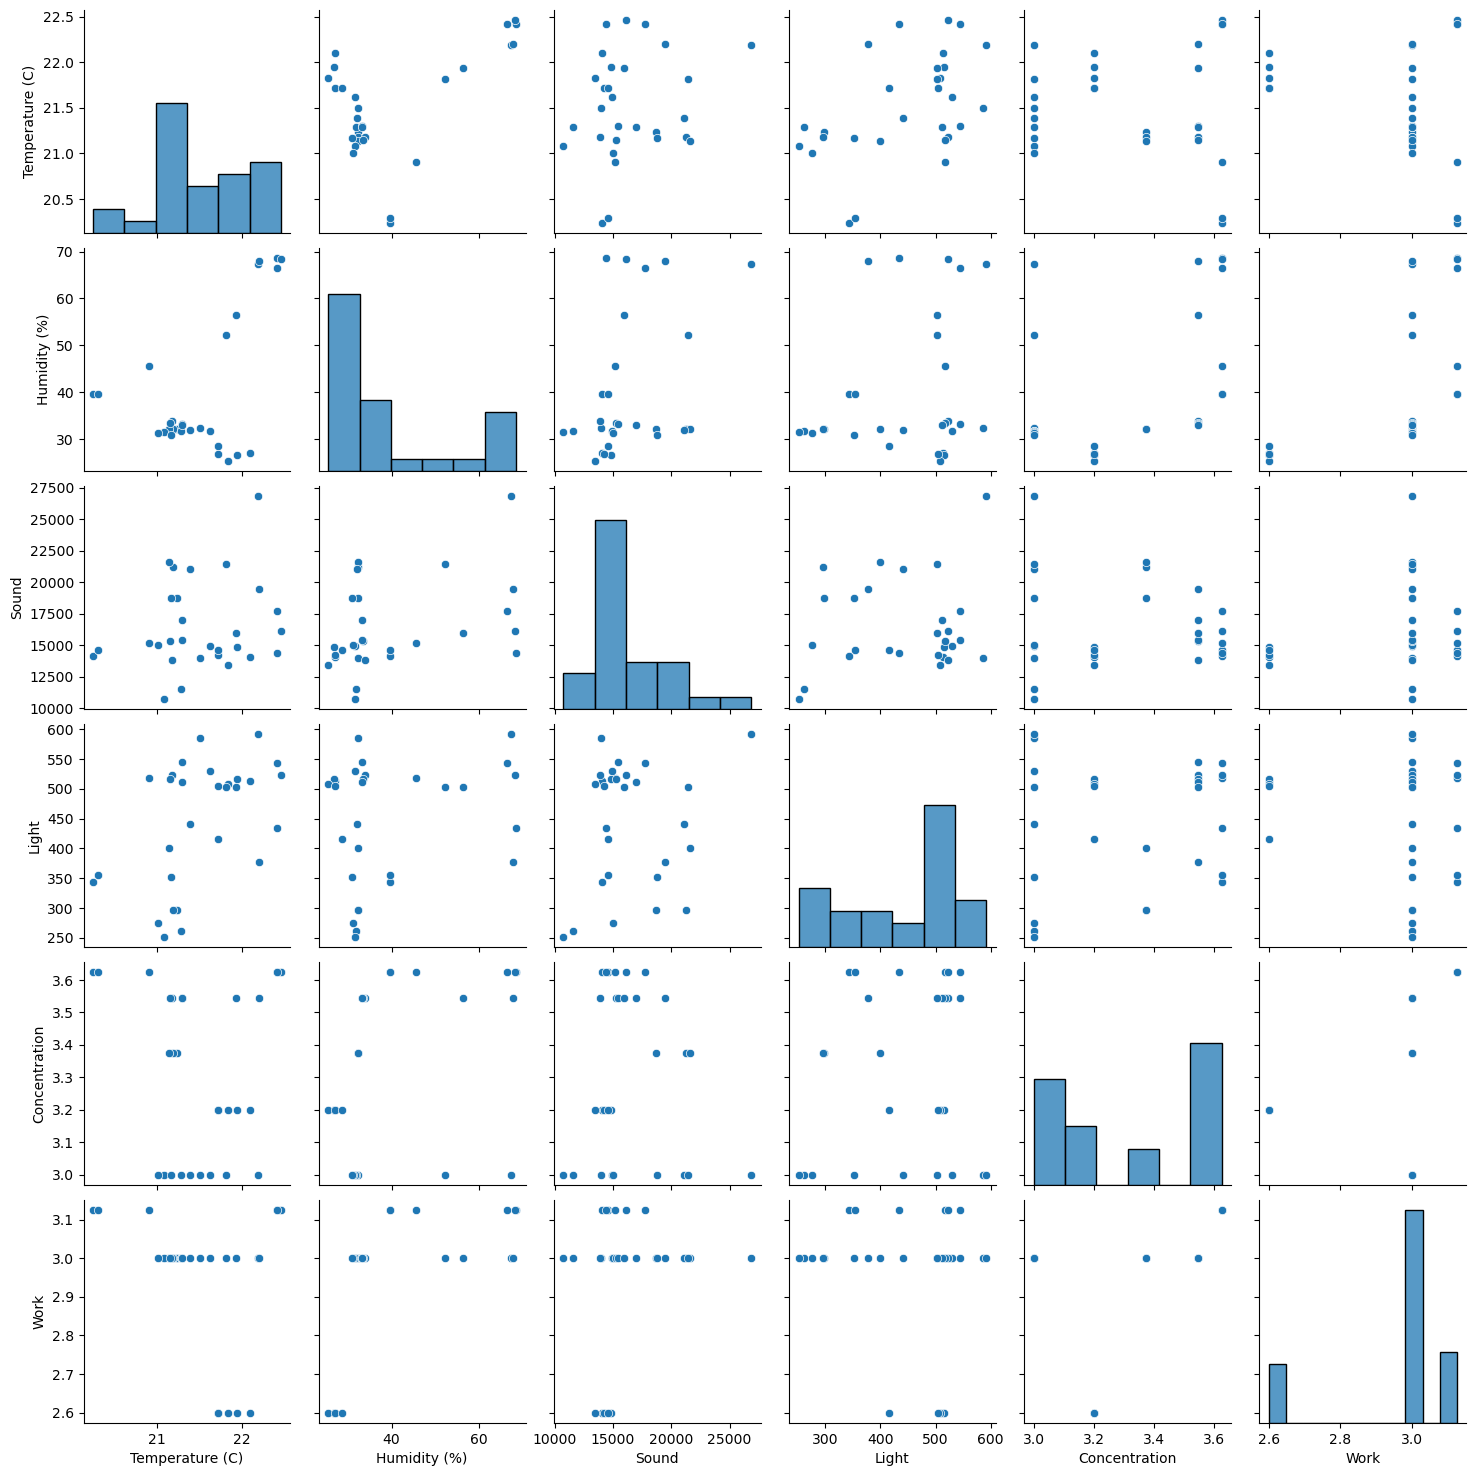

In [177]:
sns.pairplot(df)